In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
df= pd.read_csv("IPLPlayerStat.csv")

In [19]:
df.head()

,Unnamed: 0,player,runs,boundaries,balls_faced,wickets,balls_bowled,runs_conceded,matches,batting_avg,batting_strike_rate,boundaries_percent,bowling_economy,bowling_avg,bowling_strike_rate,catches,stumpings
0,0,A Ashish Reddy,280,31,196,18.0,270.0,400.0,28,10.00,142.86,15.82,8.89,22.22,15.00,8.0,0.0
1,1,A Badoni,161,18,139,2.0,12.0,12.0,11,14.64,115.83,12.95,6.00,6.00,6.00,8.0,0.0
2,2,A Chandila,4,0,7,11.0,234.0,245.0,12,0.33,57.14,0.00,6.28,22.27,21.27,2.0,0.0
3,3,A Chopra,53,7,75,0.0,0.0,0.0,6,8.83,70.67,9.33,0.00,0.00,0.00,2.0,0.0
4,4,A Choudhary,25,2,20,5.0,108.0,144.0,5,5.00,125.00,10.00,8.00,28.80,21.60,0.0,0.0


In [20]:
if 'Unnamed: 0' in df.columns:
    df.drop('Unnamed: 0',axis=1, inplace=True)

In [21]:
df.head()

,player,runs,boundaries,balls_faced,wickets,balls_bowled,runs_conceded,matches,batting_avg,batting_strike_rate,boundaries_percent,bowling_economy,bowling_avg,bowling_strike_rate,catches,stumpings
0,A Ashish Reddy,280,31,196,18.0,270.0,400.0,28,10.00,142.86,15.82,8.89,22.22,15.00,8.0,0.0
1,A Badoni,161,18,139,2.0,12.0,12.0,11,14.64,115.83,12.95,6.00,6.00,6.00,8.0,0.0
2,A Chandila,4,0,7,11.0,234.0,245.0,12,0.33,57.14,0.00,6.28,22.27,21.27,2.0,0.0
3,A Chopra,53,7,75,0.0,0.0,0.0,6,8.83,70.67,9.33,0.00,0.00,0.00,2.0,0.0
4,A Choudhary,25,2,20,5.0,108.0,144.0,5,5.00,125.00,10.00,8.00,28.80,21.60,0.0,0.0


In [23]:
df[["batting_strike_rate"]].head()

,batting_strike_rate
0,142.86
1,115.83
2,57.14
3,70.67
4,125.00


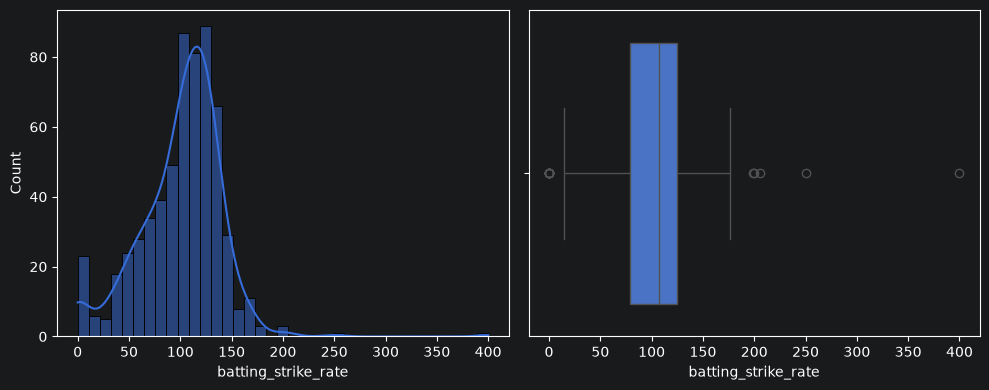

In [30]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sb.histplot(df["batting_strike_rate"],kde=True)
plt.subplot(1,2,2)
sb.boxplot(x=df["batting_strike_rate"])
plt.tight_layout()
plt.show()

In [31]:
Q1=df["batting_strike_rate"].quantile(0.25)
Q3=df["batting_strike_rate"].quantile(0.75)
IQR=Q3-Q1
lower=Q1-1.5*IQR
upper=Q3+1.5*IQR
print("Q1:",Q1)
print("Q3:",Q3)
print("IQR:",IQR)
print("lower:",lower)
print("upper:",upper)

Q1: 78.75
Q3: 125.0
IQR: 46.25
lower: 9.375
upper: 194.375


In [35]:
outliers=df[(df["batting_strike_rate"]>upper)|(df["batting_strike_rate"]<lower)]
print("number of outliers:",len(outliers))
outliers.head()

number of outliers: 28


,player,runs,boundaries,balls_faced,wickets,balls_bowled,runs_conceded,matches,batting_avg,batting_strike_rate,boundaries_percent,bowling_economy,bowling_avg,bowling_strike_rate,catches,stumpings
57,AS Roy,0,0,2,2.0,57.0,66.0,3,0.00,0.0,0.0,6.95,33.00,28.50,5.0,0.0
63,Abdur Razzak,0,0,2,0.0,14.0,29.0,1,0.00,0.0,0.0,12.43,290000.00,140000.00,0.0,0.0
65,Akash Deep,0,0,2,5.0,119.0,206.0,5,0.00,0.0,0.0,10.39,41.20,23.80,1.0,0.0
83,B Stanlake,5,1,2,7.0,150.0,200.0,6,0.83,250.0,50.0,8.00,28.57,21.43,1.0,0.0
102,C Nanda,0,0,1,2.0,50.0,58.0,3,0.00,0.0,0.0,6.96,29.00,25.00,0.0,0.0


In [37]:
trim_df=df[(df["batting_strike_rate"]<=upper)&(df["batting_strike_rate"]>=lower)]
print("original shape: ",df.shape)
print("after trimming outliers: ",trim_df.shape)

original shape:  (605, 16)
after trimming outliers:  (577, 16)


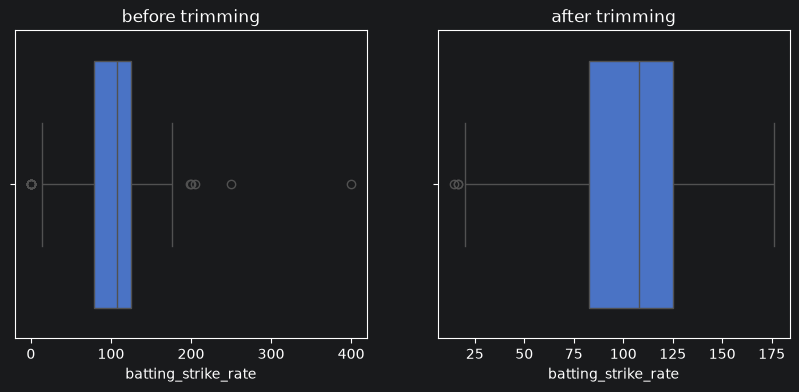

In [38]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.title("before trimming")
sb.boxplot(x=df["batting_strike_rate"])
plt.subplot(1,2,2)
plt.title("after trimming")
sb.boxplot(x=trim_df["batting_strike_rate"])
plt.show()

In [39]:
cap_df=df.copy()
cap_df["batting_strike_rate"]=cap_df["batting_strike_rate"].clip(lower,upper)
print("original shape",df.shape)
print("after capping",cap_df.shape)

original shape (605, 16)
after capping (605, 16)


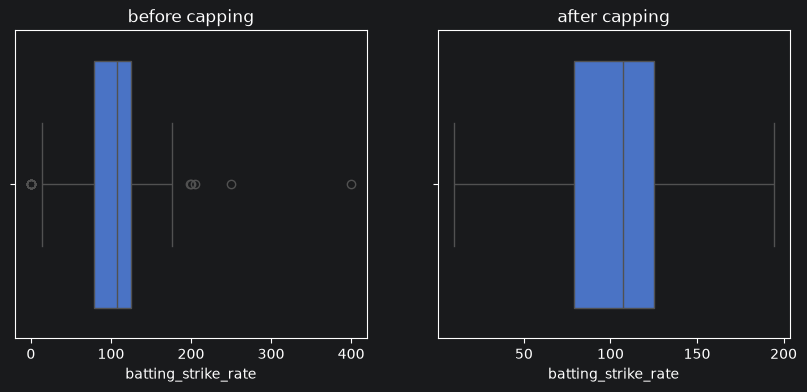

In [40]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.title("before capping")
sb.boxplot(x=df["batting_strike_rate"])
plt.subplot(1,2,2)
plt.title("after capping")
sb.boxplot(x=cap_df["batting_strike_rate"])
plt.show()